<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_09_Aluno_Metricas_Visao_Computacional_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 9 – Métricas para Visão Computacional — Revisado

## Versão do Aluno

### Capacidades
- Aplicar visão computacional.

### Conhecimentos
- Precision.
- Recall.
- IoU.
- Análise de erros.
- Matriz de confusão.

### Evidência de aprendizagem
Relatório analítico com interpretação técnica de métricas.


# 1. Contextualização

Nesta aula, você irá analisar tecnicamente os resultados de um modelo de visão computacional.

Complete:

Em visão computacional, não basta apenas treinar um modelo. Também é necessário **analisar e interpretar** os resultados.

Em uma inspeção industrial, um falso negativo pode significar que uma peça **defeituosa** foi classificada como **boa**.

Um falso positivo pode significar que uma peça **boa** foi classificada como **defeituosa**.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 2. Dataset CIFAR-10

Complete: o CIFAR-10 possui imagens coloridas de **32** x **32** pixels organizadas em **10** classes.

x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


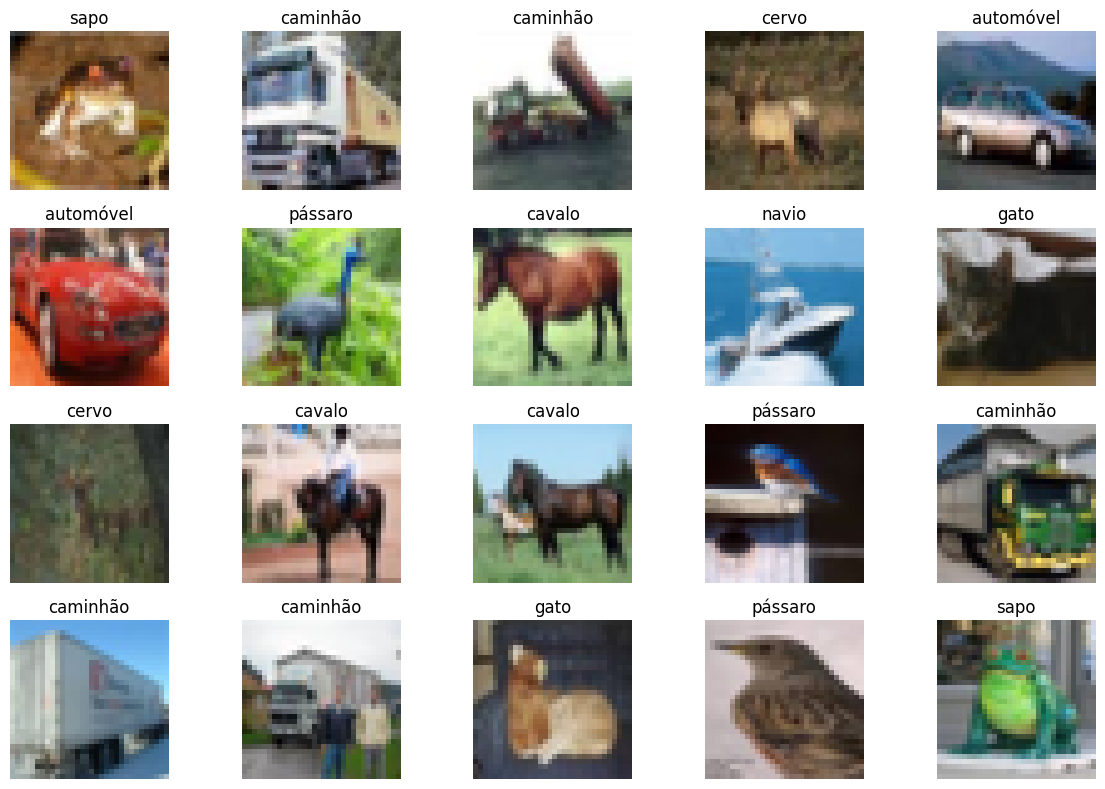

In [4]:
# Carregamento do dataset CIFAR-10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

classes = [
    "avião", "automóvel", "pássaro", "gato", "cervo",
    "cachorro", "sapo", "cavalo", "navio", "caminhão"
]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

plt.figure(figsize=(12, 8))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(classes[int(y_train[i][0])])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 3. Preparação dos dados

Complete os campos em branco para normalizar os pixels e criar subconjuntos didáticos.

In [8]:
# Normalização dos pixels e criação de subconjunto didático

x_train_norm = x_train.astype("float32") / 255.0
x_test_norm = x_test.astype("float32") / 255.0

x_train_small = x_train_norm[:5000]
y_train_small = y_train[:5000]

x_test_small = x_test_norm[:1000]
y_test_small = y_test[:1000]

print("Treino:", x_train_small.shape, y_train_small.shape)
print("Teste:", x_test_small.shape, y_test_small.shape)

Treino: (5000, 32, 32, 3) (5000, 1)
Teste: (1000, 32, 32, 3) (1000, 1)


# 4. Treinamento de uma CNN

Complete a arquitetura e os parâmetros de treinamento.

In [9]:
# Construção e treinamento de uma CNN simples para gerar resultados de análise

modelo = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax") # 10 classes para CIFAR-10
])

modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

modelo.summary()

historico = modelo.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.2200 - loss: 2.0718 - val_accuracy: 0.2990 - val_loss: 1.8753
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3873 - loss: 1.7032 - val_accuracy: 0.4280 - val_loss: 1.6299
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.4535 - loss: 1.5378 - val_accuracy: 0.4610 - val_loss: 1.5363
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.4880 - loss: 1.4320 - val_accuracy: 0.4470 - val_loss: 1.5889
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5033 - loss: 1.3639 - val_accuracy: 0.4740 - val_loss: 1.5109
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.5452 - loss: 1.2786 - val_accuracy: 0.5000 - val_loss: 1.4136
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5775 - loss: 1.2001 - val_accuracy: 0.5110 - val_loss: 1.3850
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.6062 - loss: 1.1123 - val_accu

# 5. Curvas de treinamento

Observe as curvas e responda: a loss diminuiu? A validação acompanhou o treino? Há indícios de overfitting?

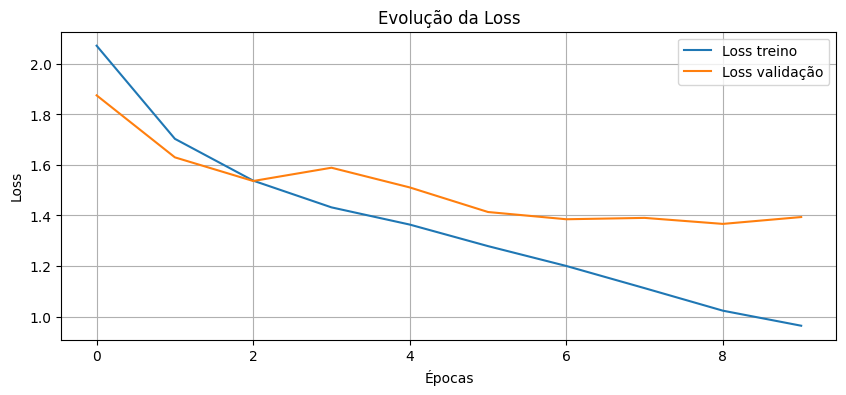

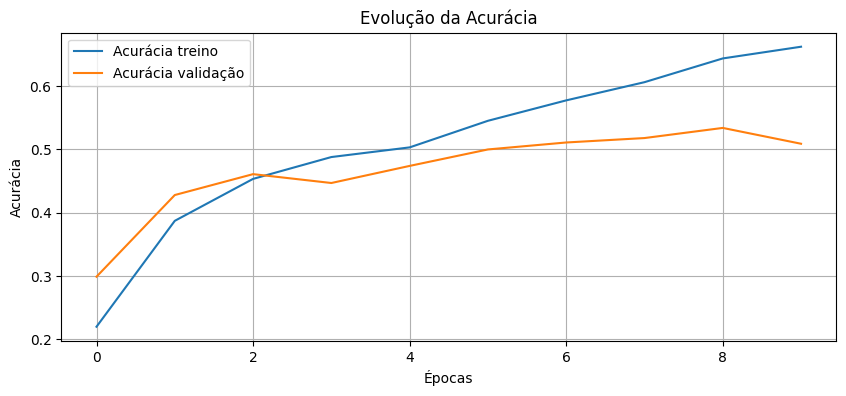

In [10]:
# Curvas de treinamento

plt.figure(figsize=(10, 4))
plt.plot(historico.history["loss"], label="Loss treino")
plt.plot(historico.history["val_loss"], label="Loss validação")
plt.title("Evolução da Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico.history["accuracy"], label="Acurácia treino")
plt.plot(historico.history["val_accuracy"], label="Acurácia validação")
plt.title("Evolução da Acurácia")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

# 6. Predições do modelo

Complete a avaliação e observe a saída de probabilidades.

In [12]:
# Predições do modelo

probabilidades = modelo.predict(x_test_small)
y_pred = np.argmax(probabilidades, axis=1)
y_true = y_test_small.flatten()

loss_teste, acc_teste = modelo.evaluate(x_test_small, y_test_small, verbose=0)

print(f"Loss no teste: {loss_teste:.4f}")
print(f"Accuracy no teste: {acc_teste:.4f}")

print("\nExemplo de saída do modelo para a primeira imagem:")
print(probabilidades[0])

print("\nClasse real:", classes[y_true[0]])
print("Classe prevista:", classes[y_pred[0]])
print("Confiança da previsão:", np.max(probabilidades[0]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Loss no teste: 1.4035
Accuracy no teste: 0.5270

Exemplo de saída do modelo para a primeira imagem:
[0.00805486 0.00074797 0.40325245 0.29373765 0.00480688 0.14465208
 0.09376997 0.00367988 0.04647302 0.00082532]

Classe real: gato
Classe prevista: pássaro
Confiança da previsão: 0.40325245


# 7. Matriz de confusão

Complete:

- Cada linha representa a classe **real**.
- Cada coluna representa a classe **prevista**.
- A diagonal principal representa os **acertos** (Verdadeiros Positivos).
- Valores fora da diagonal representam os **erros** (falsos positivos e falsos negativos).

Em uma aplicação industrial, a matriz de confusão ajuda a identificar **os tipos específicos de erros que o modelo está cometendo**.

<Figure size 1000x1000 with 0 Axes>

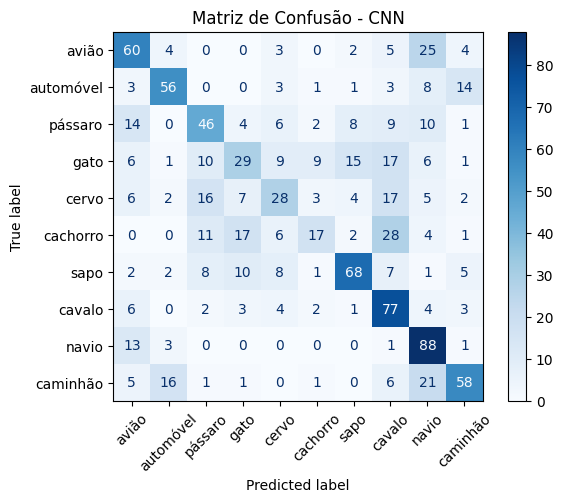

Linhas = classes reais
Colunas = classes previstas


In [13]:
# Matriz de confusão

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - CNN")
plt.show()

print("Linhas = classes reais")
print("Colunas = classes previstas")

# 8. Precision e Recall — passo a passo

Para entender precision e recall, vamos analisar uma classe específica.

Complete:

## Verdadeiro Positivo — VP
O modelo disse que era a classe analisada e realmente **era da classe analisada**.

## Falso Positivo — FP
O modelo disse que era a classe analisada, mas **não era da classe analisada**.

## Falso Negativo — FN
A imagem era da classe analisada, mas o modelo **não a identificou como tal**.

## Fórmulas

```text
Precision = VP / (VP + FP)
Recall = VP / (VP + FN)
```

Interpretação:

- Precision baixa indica muitos **falsos positivos**.
- Recall baixo indica muitos **falsos negativos**.

In [15]:
# Exemplo didático de Precision e Recall para uma classe específica

classe_interesse = "automóvel"
indice_classe = classes.index(classe_interesse)

# Para uma classe específica, transformamos o problema multiclasse em binário:
# classe de interesse = positivo
# todas as outras classes = negativo

y_true_bin = (y_true == indice_classe).astype(int)
y_pred_bin = (y_pred == indice_classe).astype(int)

VP = np.sum((y_true_bin == 1) & (y_pred_bin == 1))  # Verdadeiro Positivo
FP = np.sum((y_true_bin == 0) & (y_pred_bin == 1))  # Falso Positivo
FN = np.sum((y_true_bin == 1) & (y_pred_bin == 0))  # Falso Negativo
VN = np.sum((y_true_bin == 0) & (y_pred_bin == 0))  # Verdadeiro Negativo

precision_manual = VP / (VP + FP) if (VP + FP) > 0 else 0
recall_manual = VP / (VP + FN) if (VP + FN) > 0 else 0

print("Classe analisada:", classe_interesse)
print("VP - Verdadeiro Positivo:", VP)
print("FP - Falso Positivo:", FP)
print("FN - Falso Negativo:", FN)
print("VN - Verdadeiro Negativo:", VN)

print("\nPrecision manual:", round(precision_manual, 4))
print("Recall manual:", round(recall_manual, 4))

Classe analisada: automóvel
VP - Verdadeiro Positivo: 56
FP - Falso Positivo: 28
FN - Falso Negativo: 33
VN - Verdadeiro Negativo: 883

Precision manual: 0.6667
Recall manual: 0.6292


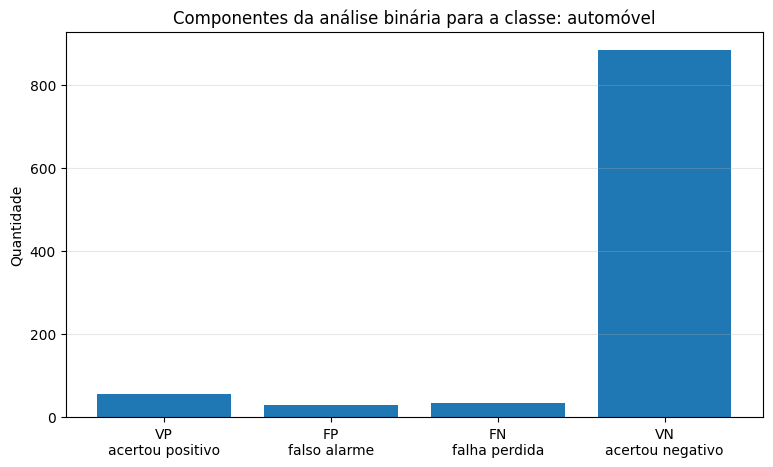

Interpretação:
- Precision olha para VP e FP: entre tudo que o modelo chamou de positivo, quanto estava certo?
- Recall olha para VP e FN: entre tudo que era realmente positivo, quanto o modelo encontrou?


In [16]:
# Visualização didática dos componentes de Precision e Recall

valores = [VP, FP, FN, VN]
rotulos = ["VP\nacertou positivo", "FP\nfalso alarme", "FN\nfalha perdida", "VN\nacertou negativo"]

plt.figure(figsize=(9, 5))
plt.bar(rotulos, valores)
plt.title(f"Componentes da análise binária para a classe: {classe_interesse}")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Interpretação:")
print("- Precision olha para VP e FP: entre tudo que o modelo chamou de positivo, quanto estava certo?")
print("- Recall olha para VP e FN: entre tudo que era realmente positivo, quanto o modelo encontrou?")

# 9. Métricas por classe

Execute a célula e interprete os resultados.

Complete:

- Precision alta significa que, quando o modelo prevê uma classe, ele geralmente **está correto**.
- Precision baixa significa que o modelo gera muitos **falsos positivos**.
- Recall alto significa que o modelo encontra muitos casos **reais** daquela classe.
- Recall baixo significa que o modelo deixa muitos casos reais **sem serem detectados (falsos negativos)**.

Relatório de classificação:
              precision    recall  f1-score   support

       avião       0.52      0.58      0.55       103
   automóvel       0.67      0.63      0.65        89
     pássaro       0.49      0.46      0.47       100
        gato       0.41      0.28      0.33       103
       cervo       0.42      0.31      0.36        90
    cachorro       0.47      0.20      0.28        86
        sapo       0.67      0.61      0.64       112
      cavalo       0.45      0.75      0.57       102
       navio       0.51      0.83      0.63       106
    caminhão       0.64      0.53      0.58       109

    accuracy                           0.53      1000
   macro avg       0.53      0.52      0.51      1000
weighted avg       0.53      0.53      0.51      1000



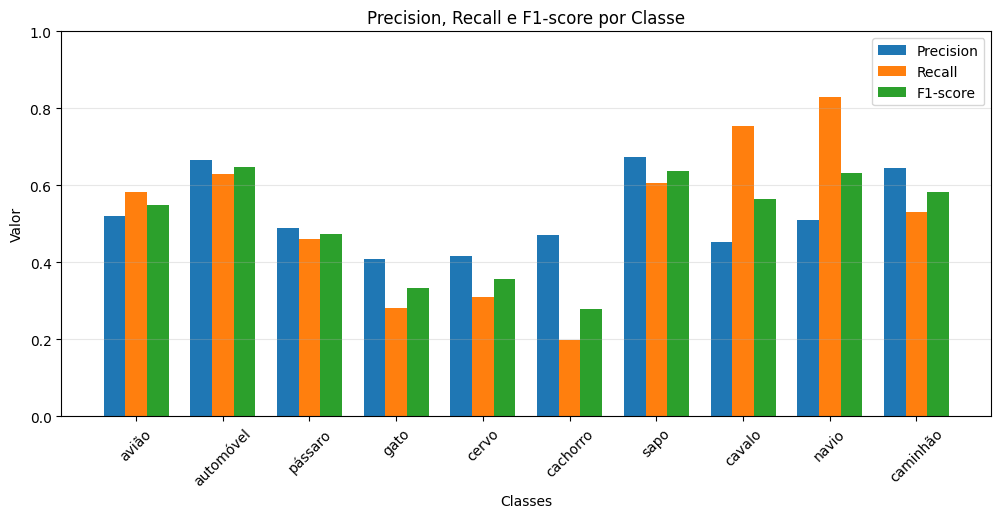

avião        | Precision: 0.522 | Recall: 0.583 | F1: 0.550
automóvel    | Precision: 0.667 | Recall: 0.629 | F1: 0.647
pássaro      | Precision: 0.489 | Recall: 0.460 | F1: 0.474
gato         | Precision: 0.408 | Recall: 0.282 | F1: 0.333
cervo        | Precision: 0.418 | Recall: 0.311 | F1: 0.357
cachorro     | Precision: 0.472 | Recall: 0.198 | F1: 0.279
sapo         | Precision: 0.673 | Recall: 0.607 | F1: 0.638
cavalo       | Precision: 0.453 | Recall: 0.755 | F1: 0.566
navio        | Precision: 0.512 | Recall: 0.830 | F1: 0.633
caminhão     | Precision: 0.644 | Recall: 0.532 | F1: 0.583


In [17]:
# Cálculo de Precision, Recall e F1-score por classe

precision_por_classe = precision_score(y_true, y_pred, average=None, zero_division=0)
recall_por_classe = recall_score(y_true, y_pred, average=None, zero_division=0)
f1_por_classe = f1_score(y_true, y_pred, average=None, zero_division=0)

print("Relatório de classificação:")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

x = np.arange(len(classes))
largura = 0.25

plt.figure(figsize=(12, 5))
plt.bar(x - largura, precision_por_classe, width=largura, label="Precision")
plt.bar(x, recall_por_classe, width=largura, label="Recall")
plt.bar(x + largura, f1_por_classe, width=largura, label="F1-score")
plt.xticks(x, classes, rotation=45)
plt.ylim(0, 1)
plt.title("Precision, Recall e F1-score por Classe")
plt.xlabel("Classes")
plt.ylabel("Valor")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

for i, classe in enumerate(classes):
    print(f"{classe:12s} | Precision: {precision_por_classe[i]:.3f} | Recall: {recall_por_classe[i]:.3f} | F1: {f1_por_classe[i]:.3f}")

# 10. Interpretação automática

Registre os resultados:

- Classe com maior precision: **automóvel**
- Classe com menor precision: **gato**
- Classe com maior recall: **navio**
- Classe com menor recall: **cachorro**

Depois responda:

Em uma inspeção industrial, qual seria mais grave: baixa precision ou baixo recall? Justifique conforme o cenário.

**Resposta:**

Em uma inspeção industrial, a gravidade de baixa precision versus baixo recall depende do cenário e dos custos associados a cada tipo de erro:

-   **Baixo Recall (muitos Falsos Negativos)**: Geralmente é mais grave em cenários onde a falha em detectar um defeito (um falso negativo) pode ter consequências sérias. Por exemplo, em peças críticas de segurança (automotivas, aeronáuticas, médicas), um produto defeituoso que passa pela inspeção pode causar acidentes, falhas de equipamentos, danos à saúde do consumidor, recalls caros e perda de reputação. Nesses casos, é preferível ter alguns falsos positivos (baixa precision) a deixar um defeito passar.

-   **Baixa Precision (muitos Falsos Positivos)**: É mais grave em cenários onde o custo de rejeitar um item bom é muito alto. Por exemplo, se o processo de re-inspeção, descarte ou retrabalho de um produto é extremamente caro, ter muitos falsos positivos significa perda financeira significativa com o descarte de peças que estavam boas ou com o custo desnecessário de processos adicionais. Nesses casos, o sistema precisa ser mais preciso para evitar perdas econômicas.

No geral, para a maioria das **inspeções industriais de qualidade e segurança**, o **baixo recall** é frequentemente considerado o mais grave, pois um defeito não detectado pode ter implicações catastróficas em termos de segurança, responsabilidade legal e reputação da marca, superando os custos de alguns falsos positivos.

In [18]:
# Interpretação automática das métricas

idx_maior_precision = np.argmax(precision_por_classe)
idx_menor_precision = np.argmin(precision_por_classe)
idx_maior_recall = np.argmax(recall_por_classe)
idx_menor_recall = np.argmin(recall_por_classe)

print("Classe com maior precision:", classes[idx_maior_precision], "-", round(precision_por_classe[idx_maior_precision], 4))
print("Classe com menor precision:", classes[idx_menor_precision], "-", round(precision_por_classe[idx_menor_precision], 4))
print("Classe com maior recall:", classes[idx_maior_recall], "-", round(recall_por_classe[idx_maior_recall], 4))
print("Classe com menor recall:", classes[idx_menor_recall], "-", round(recall_por_classe[idx_menor_recall], 4))

print("\nRoteiro de interpretação:")
print("1. Baixa precision indica muitos falsos positivos.")
print("2. Baixo recall indica muitos falsos negativos.")
print("3. Em inspeção industrial crítica, baixo recall pode ser grave, pois significa deixar defeitos passarem.")
print("4. Em inspeção com alto custo de descarte, baixa precision pode ser grave, pois descarta peças boas.")

Classe com maior precision: sapo - 0.6733
Classe com menor precision: gato - 0.4085
Classe com maior recall: navio - 0.8302
Classe com menor recall: cachorro - 0.1977

Roteiro de interpretação:
1. Baixa precision indica muitos falsos positivos.
2. Baixo recall indica muitos falsos negativos.
3. Em inspeção industrial crítica, baixo recall pode ser grave, pois significa deixar defeitos passarem.
4. Em inspeção com alto custo de descarte, baixa precision pode ser grave, pois descarta peças boas.


# 11. Análise de erros — passo a passo

A análise de erros ajuda a entender por que o modelo falhou.

Complete:

Ao analisar erros, devemos verificar:

1. Se as classes são **distinguíveis**.
2. Se a imagem está escura, cortada ou com baixa **qualidade**.
3. Se o modelo errou com alta **confiança**.
4. Se há problemas de **rotulagem** no dataset.
5. Se é necessário coletar mais **dados**.

In [19]:
# Análise de erros - identificação geral

indices_erros = np.where(y_true != y_pred)[0]
indices_acertos = np.where(y_true == y_pred)[0]
confiancas = np.max(probabilidades, axis=1)

print("Total de imagens avaliadas:", len(y_true))
print("Quantidade de acertos:", len(indices_acertos))
print("Quantidade de erros:", len(indices_erros))
print("Taxa de erro:", round(len(indices_erros) / len(y_true), 4))

Total de imagens avaliadas: 1000
Quantidade de acertos: 527
Quantidade de erros: 473
Taxa de erro: 0.473


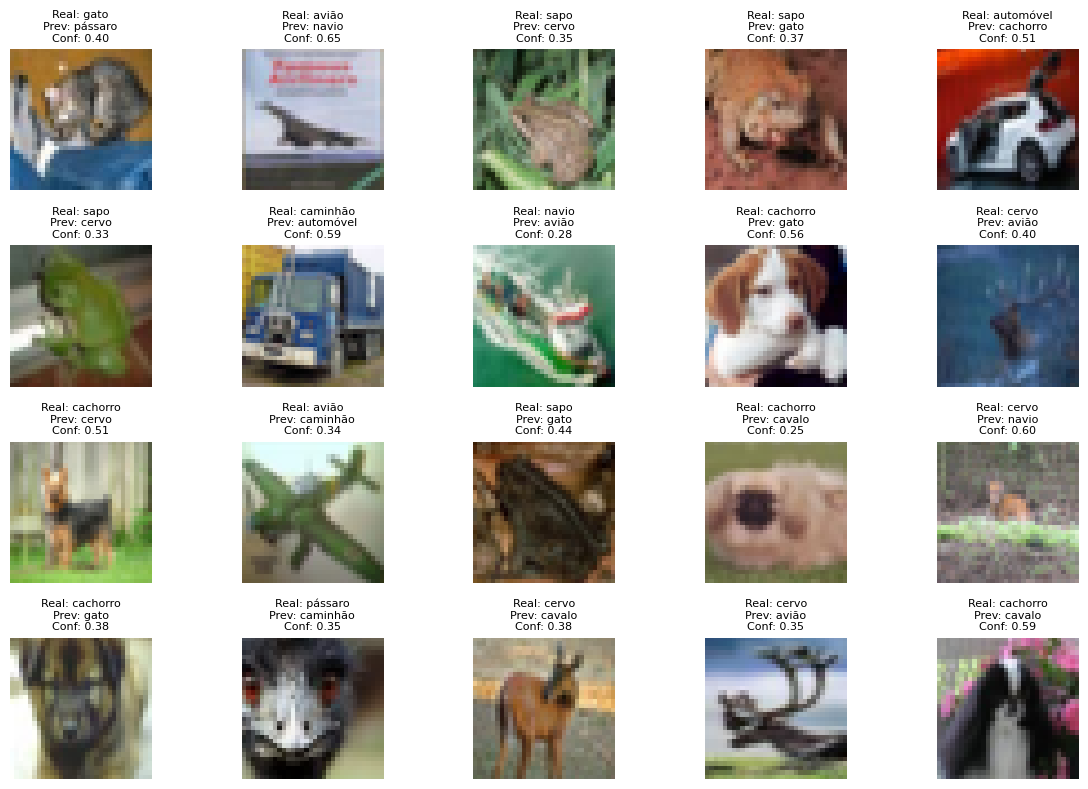

In [20]:
# Visualização dos primeiros erros

plt.figure(figsize=(12, 8))
for i, idx in enumerate(indices_erros[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[idx])
    real = classes[y_true[idx]]
    previsto = classes[y_pred[idx]]
    conf = confiancas[idx]
    plt.title(f"Real: {real}\nPrev: {previsto}\nConf: {conf:.2f}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

# 12. Erros com alta confiança

Complete:

Um erro com alta confiança é preocupante porque o modelo está **errado**, mas muito **confiante** da resposta errada.

Em inspeção industrial, isso pode causar **falhas críticas ou acidentes**.

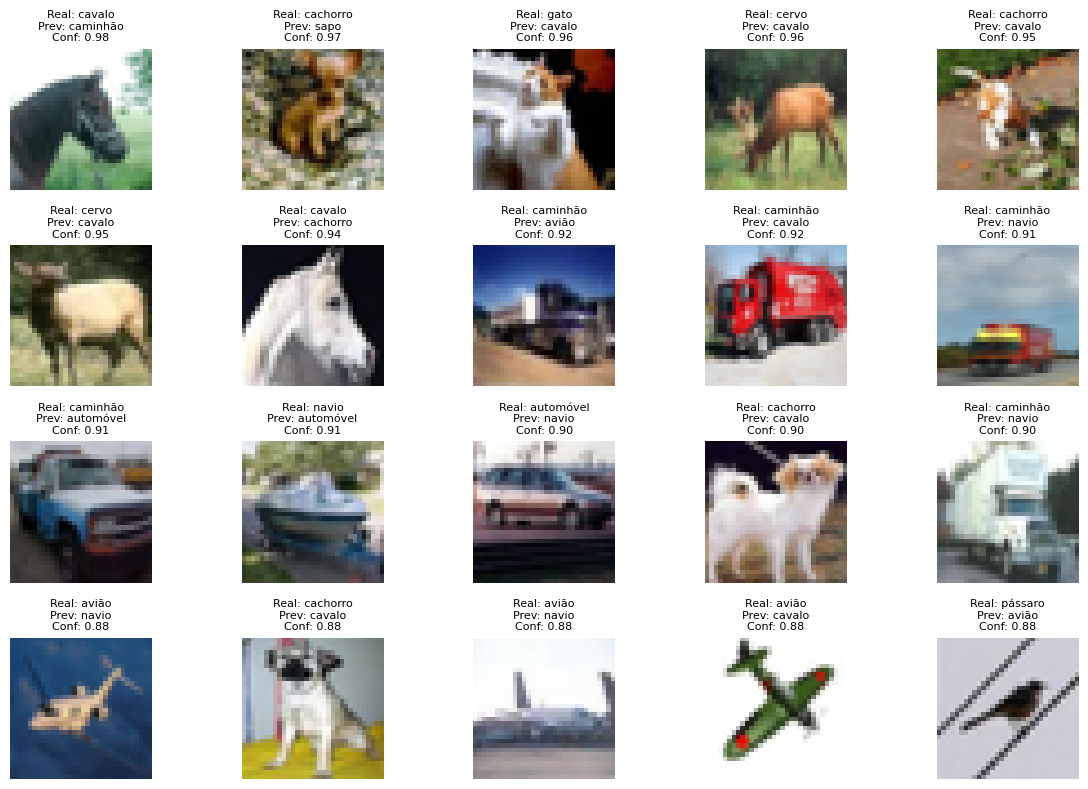

Por que analisar erros com alta confiança?
- Eles indicam que o modelo errou mesmo estando muito seguro.
- Podem revelar classes visualmente parecidas.
- Podem indicar problemas no dataset ou necessidade de mais exemplos.
- Em ambiente industrial, esses erros merecem análise prioritária.


In [21]:
# Análise dos erros com maior confiança

erros_ordenados_por_confianca = indices_erros[np.argsort(confiancas[indices_erros])[::-1]]

plt.figure(figsize=(12, 8))
for i, idx in enumerate(erros_ordenados_por_confianca[:20]):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[idx])
    real = classes[y_true[idx]]
    previsto = classes[y_pred[idx]]
    conf = confiancas[idx]
    plt.title(f"Real: {real}\nPrev: {previsto}\nConf: {conf:.2f}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

print("Por que analisar erros com alta confiança?")
print("- Eles indicam que o modelo errou mesmo estando muito seguro.")
print("- Podem revelar classes visualmente parecidas.")
print("- Podem indicar problemas no dataset ou necessidade de mais exemplos.")
print("- Em ambiente industrial, esses erros merecem análise prioritária.")

# 13. Pares mais confundidos

Execute a célula e registre:

- Par mais confundido: real **navio** previsto **caminhão**.
- Possível causa da confusão: **Semelhança visual entre as classes, como o fundo do mar e os objetos grandes em ambos.**

In [22]:
# Quais confusões aconteceram com mais frequência?

pares_erros = {}

for idx in indices_erros:
    real = classes[y_true[idx]]
    previsto = classes[y_pred[idx]]
    par = (real, previsto)
    pares_erros[par] = pares_erros.get(par, 0) + 1

pares_ordenados = sorted(pares_erros.items(), key=lambda x: x[1], reverse=True)

print("Principais confusões do modelo:")
for (real, previsto), qtd in pares_ordenados[:10]:
    print(f"Real: {real:12s} -> Previsto: {previsto:12s} | Quantidade: {qtd}")

Principais confusões do modelo:
Real: cachorro     -> Previsto: cavalo       | Quantidade: 28
Real: avião        -> Previsto: navio        | Quantidade: 25
Real: caminhão     -> Previsto: navio        | Quantidade: 21
Real: cachorro     -> Previsto: gato         | Quantidade: 17
Real: cervo        -> Previsto: cavalo       | Quantidade: 17
Real: gato         -> Previsto: cavalo       | Quantidade: 17
Real: caminhão     -> Previsto: automóvel    | Quantidade: 16
Real: cervo        -> Previsto: pássaro      | Quantidade: 16
Real: gato         -> Previsto: sapo         | Quantidade: 15
Real: pássaro      -> Previsto: avião        | Quantidade: 14


# 14. IoU — explicação passo a passo

Complete:

IoU significa **Intersection over Union**.

Ela mede a sobreposição entre uma caixa **real (ground truth)** e uma caixa **prevista (predicted bounding box)**.

A fórmula é:

```text
IoU = área de __interseção__ / área de __união__
```

Interpretação:

- IoU próxima de 1 significa **sobreposição perfeita**.
- IoU próxima de 0 significa **nenhuma sobreposição**.

In [24]:
# IoU - Intersection over Union

def calcular_iou(box_real, box_pred):
    # Formato da caixa: [x1, y1, x2, y2]
    x1_real, y1_real, x2_real, y2_real = box_real
    x1_pred, y1_pred, x2_pred, y2_pred = box_pred

    # Coordenadas da interseção
    x1_inter = max(x1_real, x1_pred)
    y1_inter = max(y1_real, y1_pred)
    x2_inter = min(x2_real, x2_pred)
    y2_inter = min(y2_real, y2_pred)

    # Largura e altura da área de interseção
    largura_inter = max(0, x2_inter - x1_inter)
    altura_inter = max(0, y2_inter - y1_inter)

    area_inter = largura_inter * altura_inter

    # Áreas das caixas
    area_real = (x2_real - x1_real) * (y2_real - y1_real)
    area_pred = (x2_pred - x1_pred) * (y2_pred - y1_pred)

    # União = área real + área prevista - área de interseção
    area_uniao = area_real + area_pred - area_inter

    if area_uniao == 0:
        return 0

    return area_inter / area_uniao

box_real = [10, 10, 80, 80]
box_pred = [20, 20, 70, 70]

iou = calcular_iou(box_real, box_pred)

print("Caixa real:", box_real)
print("Caixa prevista:", box_pred)
print("IoU:", round(iou, 4))

Caixa real: [10, 10, 80, 80]
Caixa prevista: [20, 20, 70, 70]
IoU: 0.5102


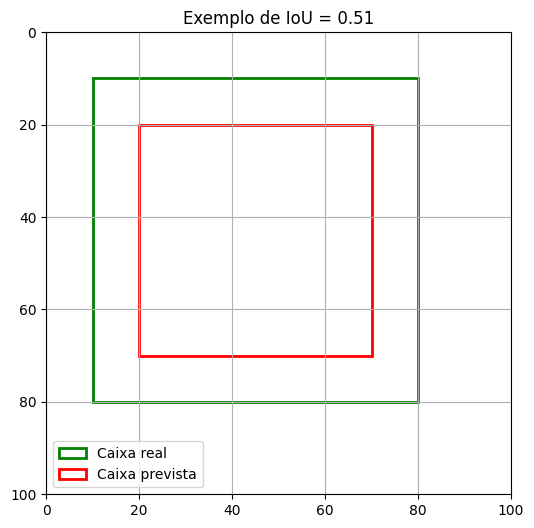

In [25]:
# Visualização gráfica da IoU

import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(0, 100)
ax.set_ylim(100, 0)
ax.set_title(f"Exemplo de IoU = {iou:.2f}")

rect_real = patches.Rectangle(
    (box_real[0], box_real[1]),
    box_real[2] - box_real[0],
    box_real[3] - box_real[1],
    linewidth=2,
    edgecolor="green",
    facecolor="none",
    label="Caixa real"
)

rect_pred = patches.Rectangle(
    (box_pred[0], box_pred[1]),
    box_pred[2] - box_pred[0],
    box_pred[3] - box_pred[1],
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    label="Caixa prevista"
)

ax.add_patch(rect_real)
ax.add_patch(rect_pred)
ax.legend()
ax.grid(True)
plt.show()

# 15. Comparação de IoU

Execute a célula e responda:

1. Qual caixa teve melhor IoU?

   **Caixa 1 (IoU de 0.7259)**

2. Qual caixa teve pior IoU?

   **Caixa 5 (IoU de 0.0 - sem sobreposição)**

3. O que significa IoU maior ou igual a 0,5?

   **Geralmente, IoU >= 0.5 é considerado um limiar para uma detecção
   aceitável, indicando que há uma sobreposição significativa entre a caixa prevista e a caixa real.**

4. Em uma inspeção industrial crítica, você usaria IoU 0,5 ou exigiria valor maior? Justifique.

   **Em uma inspeção industrial crítica, eu exigiria um valor de IoU maior que 0.5, como 0.7 ou 0.8. Isso ocorre porque em cenários críticos (onde a falha em identificar um defeito pode ter consequências graves), é essencial que a localização do defeito seja o mais precisa possível. Um IoU de 0.5 ainda pode significar que uma parte considerável do defeito real não foi coberta pela previsão ou que a previsão inclui muita área não relevante. Valores mais altos garantem uma maior fidelidade entre a detecção do modelo e o real defeito.**

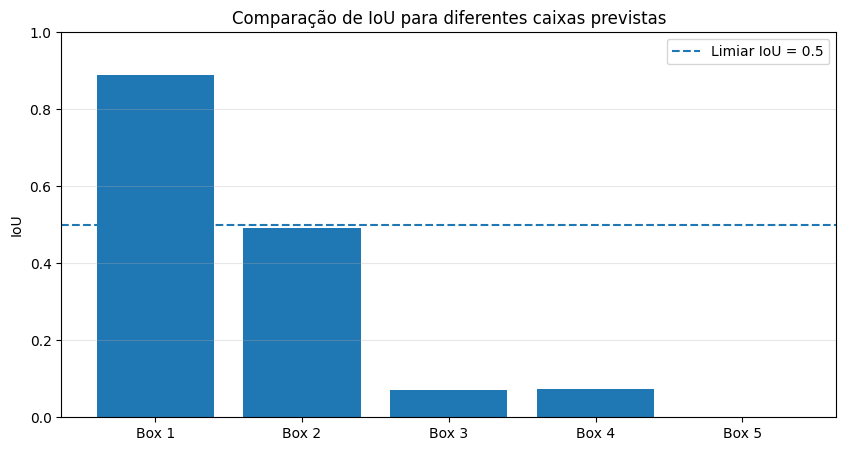

Box 1: [12, 12, 78, 78] | IoU = 0.8890 -> detecção aceitável
Box 2: [30, 20, 90, 90] | IoU = 0.4918 -> detecção ruim
Box 3: [60, 60, 95, 95] | IoU = 0.0699 -> detecção ruim
Box 4: [0, 0, 30, 30] | IoU = 0.0741 -> detecção ruim
Box 5: [85, 85, 95, 95] | IoU = 0.0000 -> detecção ruim


In [26]:
# Comparação de diferentes caixas previstas

boxes_preditas = [
    [12, 12, 78, 78],   # muito próxima da real
    [30, 20, 90, 90],   # sobreposição parcial
    [60, 60, 95, 95],   # baixa sobreposição
    [0, 0, 30, 30],     # baixa sobreposição
    [85, 85, 95, 95]    # sem sobreposição
]

valores_iou = []

for box in boxes_preditas:
    valores_iou.append(calcular_iou(box_real, box))

plt.figure(figsize=(10, 5))
plt.bar([f"Box {i+1}" for i in range(len(boxes_preditas))], valores_iou)
plt.axhline(0.5, linestyle="--", label="Limiar IoU = 0.5")
plt.ylim(0, 1)
plt.title("Comparação de IoU para diferentes caixas previstas")
plt.ylabel("IoU")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

for i, (box, valor) in enumerate(zip(boxes_preditas, valores_iou)):
    status = "detecção aceitável" if valor >= 0.5 else "detecção ruim"
    print(f"Box {i+1}: {box} | IoU = {valor:.4f} -> {status}")

# 16. Relatório analítico final

Responda no final do notebook:

1. Qual foi a accuracy geral do modelo?
   **A accuracy geral do modelo no conjunto de teste foi de 0.5270 (52.7%).**

2. A accuracy foi suficiente para avaliar o modelo? Justifique.
   **Não, a accuracy isoladamente não é suficiente para avaliar o modelo, especialmente em inspeções industriais. Embora seja uma métrica geral, ela não revela o desempenho do modelo em cada classe individualmente, nem a natureza dos erros (Falsos Positivos vs. Falsos Negativos), que são cruciais para cenários onde diferentes tipos de erros têm custos muito distintos.**

3. Qual classe apresentou maior precision?
   **A classe 'sapo' apresentou a maior precision, com 0.673.**

4. Qual classe apresentou menor precision?
   **A classe 'gato' apresentou a menor precision, com 0.408.**

5. Qual classe apresentou maior recall?
   **A classe 'navio' apresentou o maior recall, com 0.830.**

6. Qual classe apresentou menor recall?
   **A classe 'cachorro' apresentou o menor recall, com 0.198.**

7. O que significa uma classe ter baixa precision?
   **Uma classe com baixa precision significa que, quando o modelo prevê essa classe, ele frequentemente está errado; ou seja, ele gera muitos Falsos Positivos (identifica incorretamente outras classes como sendo esta).**

8. O que significa uma classe ter baixo recall?
   **Uma classe com baixo recall significa que o modelo falha em identificar muitos dos casos reais dessa classe; ou seja, ele gera muitos Falsos Negativos (não detecta a classe quando ela realmente está presente).**

9. Quais foram os principais pares de classes confundidos?
   **Os principais pares de classes confundidos foram:
   - Real: cachorro -> Previsto: cavalo (28 vezes)
   - Real: avião -> Previsto: navio (25 vezes)
   - Real: caminhão -> Previsto: navio (21 vezes)**

10. O modelo apresentou erros com alta confiança?
    **Sim, o modelo apresentou erros com alta confiança. Isso foi visualizado na seção de 'Análise dos erros com maior confiança', onde algumas previsões incorretas foram feitas com um alto grau de certeza pelo modelo.**

11. O que esses erros indicam?
    **Erros com alta confiança são preocupantes porque indicam que o modelo está errado apesar de estar muito seguro de sua resposta. Isso pode revelar que as classes são visualmente muito parecidas, ou que há problemas no dataset (como rotulagem incorreta), ou ainda que o modelo generaliza mal para certos exemplos, o que pode ser perigoso em aplicações críticas.**

12. O que é IoU?
    **IoU (Intersection over Union) é uma métrica usada para avaliar a sobreposição entre uma caixa delimitadora prevista por um modelo (predicted bounding box) e a caixa delimitadora real (ground truth bounding box).**

13. Como a IoU é calculada?
    **A IoU é calculada dividindo a área de interseção entre as duas caixas (real e prevista) pela área da união dessas duas caixas. A fórmula é: IoU = Área da Interseção / Área da União.**

14. Como a IoU se aplica à inspeção visual industrial?
    **Na inspeção visual industrial, a IoU é fundamental para determinar a precisão da localização de defeitos. Um IoU alto indica que o modelo localizou o defeito com grande exatidão. Em cenários críticos, onde a localização precisa do defeito é vital (por exemplo, para reparo automatizado ou descarte específico), exige-se um valor de IoU mais alto (e.g., > 0.7 ou 0.8) para garantir que o sistema de inspeção esteja identificando corretamente a extensão e a posição exata do problema.**

15. Quais limitações do treinamento foram identificadas?
    **As principais limitações identificadas foram:
    - **Tamanho reduzido do dataset:** Foram utilizados apenas 5000 imagens para treino e 1000 para teste, o que é um subconjunto muito pequeno do CIFAR-10 original e limita a capacidade de generalização do modelo.
    - **Overfitting incipiente:** As curvas de treinamento (loss e accuracy) mostraram que, embora o modelo estivesse aprendendo, a performance na validação não acompanhou perfeitamente a do treino, sugerindo que o modelo pode começar a superajustar aos dados de treino.
    - **Modelo simples:** A arquitetura da CNN utilizada é relativamente simples para a complexidade das imagens do CIFAR-10, o que pode limitar sua capacidade de extrair características mais robustas.**

16. Quais melhorias poderiam ser propostas?
    **Para melhorar o desempenho do modelo, as seguintes ações poderiam ser propostas:
    - **Aumentar o dataset de treinamento:** Utilizar o dataset CIFAR-10 completo ou aplicar técnicas de aumento de dados (data augmentation) para gerar mais exemplos.
    - **Arquitetura de modelo mais complexa:** Empregar modelos pré-treinados (Transfer Learning) como ResNet, VGG ou MobileNet, ou projetar uma CNN mais profunda e com mais camadas convolucionais/densas.
    - **Ajuste de hiperparâmetros:** Otimizar a taxa de aprendizado, batch size, número de épocas e regularização (dropout).
    - **Análise de classes desbalanceadas:** Se algumas classes tiverem menos exemplos, técnicas de balanceamento de classes podem ser aplicadas.
    - **Treinamento por mais épocas:** Observar as curvas de validação para determinar se mais épocas de treinamento poderiam levar a uma melhor performance antes do overfitting.
    - **Estratégias de Regularização:** Adicionar mais camadas de Dropout ou regularização L1/L2 para evitar overfitting.**